## Домашнее задание 4



**Датасет** описывает сотрудников и факт их ухода из компании (`Attrition:` Yes/No).

_Примеры полей:_

_Целевой признак:_ `Attrition (Yes/No)`.

_Числовые:_ `Age`, `DailyRate`, `DistanceFromHome`, `HourlyRate`, `MonthlyIncome`, `MonthlyRate`, `NumCompaniesWorked`, `PercentSalaryHike`, `TotalWorkingYears`, `TrainingTimesLastYear`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager` и др.

_Категориальные:_ `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`

_Ординальные шкалы (1–4/5):_ `Education`, `EnvironmentSatisfaction`, `JobInvolvement`, `JobLevel`, `JobSatisfaction`, `PerformanceRating`, `RelationshipSatisfaction`, `WorkLifeBalance`.

### Задача:

**Пропуски и аномальные/невозможные значения** (2 балла)

* Подсчитать пропуски по столбцам, обработать, обосновать стратегию
* Проверить невозможные/подозрительные значения

**Дубликаты и консистентность** ( 1 балл)

Найти полные дубликаты (`df.duplicated()`), удалить при наличии. При частичных дублях — описать проверку

**Выбросы в числовых признаках** (3 балла)

* Выбрать релевантные числовые признаки и выявить выбросы (IQR и/или z-score), визуализировать (ящики, гистограммы).

* Обосновать стратегию обработки.

* Реализовать выбранную стратегию

Если выбросов нет - просто сделать исследование.

**Обработка категориальных признаков** (2 балла)

* Разделить на номинальные и ординальные:
* Перекодировать номинальные
* Перекодировать ординальные

**Масштабирование числовых признаков** (2 балла)

* Выбрать способ: StandardScaler или MinMax/RobustScaler. Обосновать.
* Реализовать масштабирование

Загрузим библиотеки, которые могут нам понадобиться

In [ ]:
# Импорт пакетов
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (24,16)
v = None

Загрузим датасет и выведем первые пять строк его содержимого

In [ ]:
# Чтение данных
df = pd.read_csv("datahr.xls")
# Смотрим размер датасета, типы данных по столбцам и первые 5 строк с данными
print('Размер датасета (количество строк, столбцов):', df.shape)
print('Типы данных по столбцам:\n', df.dtypes)
df.head()

Размер датасета (количество строк, столбцов): (1473, 36)
Типы данных по столбцам:
 Unnamed: 0                    int64
Age                         float64
Attrition                    object
BusinessTravel               object
DailyRate                   float64
Department                   object
DistanceFromHome            float64
Education                   float64
EducationField               object
EmployeeCount               float64
EmployeeNumber              float64
EnvironmentSatisfaction     float64
Gender                       object
HourlyRate                  float64
JobInvolvement              float64
JobLevel                    float64
JobRole                      object
JobSatisfaction             float64
MaritalStatus                object
MonthlyIncome               float64
MonthlyRate                 float64
NumCompaniesWorked          float64
Over18                       object
OverTime                     object
PercentSalaryHike           float64
PerformanceRating

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,1.0,...,4.0,80.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,...,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,...,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


Наш датасет состоит из 1473 строк и 36 столбцов

In [ ]:
# Отбор числовых колонок
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print('Столбцы с числовыми колонками:', numeric_cols)

# Отбор нечисловых колонок
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print('Столбцы с нечисловыми колонками:', non_numeric_cols)


Столбцы с числовыми колонками: ['Unnamed: 0' 'Age' 'DailyRate' 'DistanceFromHome' 'Education'
 'EmployeeCount' 'EmployeeNumber' 'EnvironmentSatisfaction' 'HourlyRate'
 'JobInvolvement' 'JobLevel' 'JobSatisfaction' 'MonthlyIncome'
 'MonthlyRate' 'NumCompaniesWorked' 'PercentSalaryHike'
 'PerformanceRating' 'RelationshipSatisfaction' 'StandardHours'
 'StockOptionLevel' 'TotalWorkingYears' 'TrainingTimesLastYear'
 'WorkLifeBalance' 'YearsAtCompany' 'YearsInCurrentRole'
 'YearsSinceLastPromotion' 'YearsWithCurrManager']
Столбцы с нечисловыми колонками: ['Attrition' 'BusinessTravel' 'Department' 'EducationField' 'Gender'
 'JobRole' 'MaritalStatus' 'Over18' 'OverTime']


**1.1. Начинаем работать с пропусками**

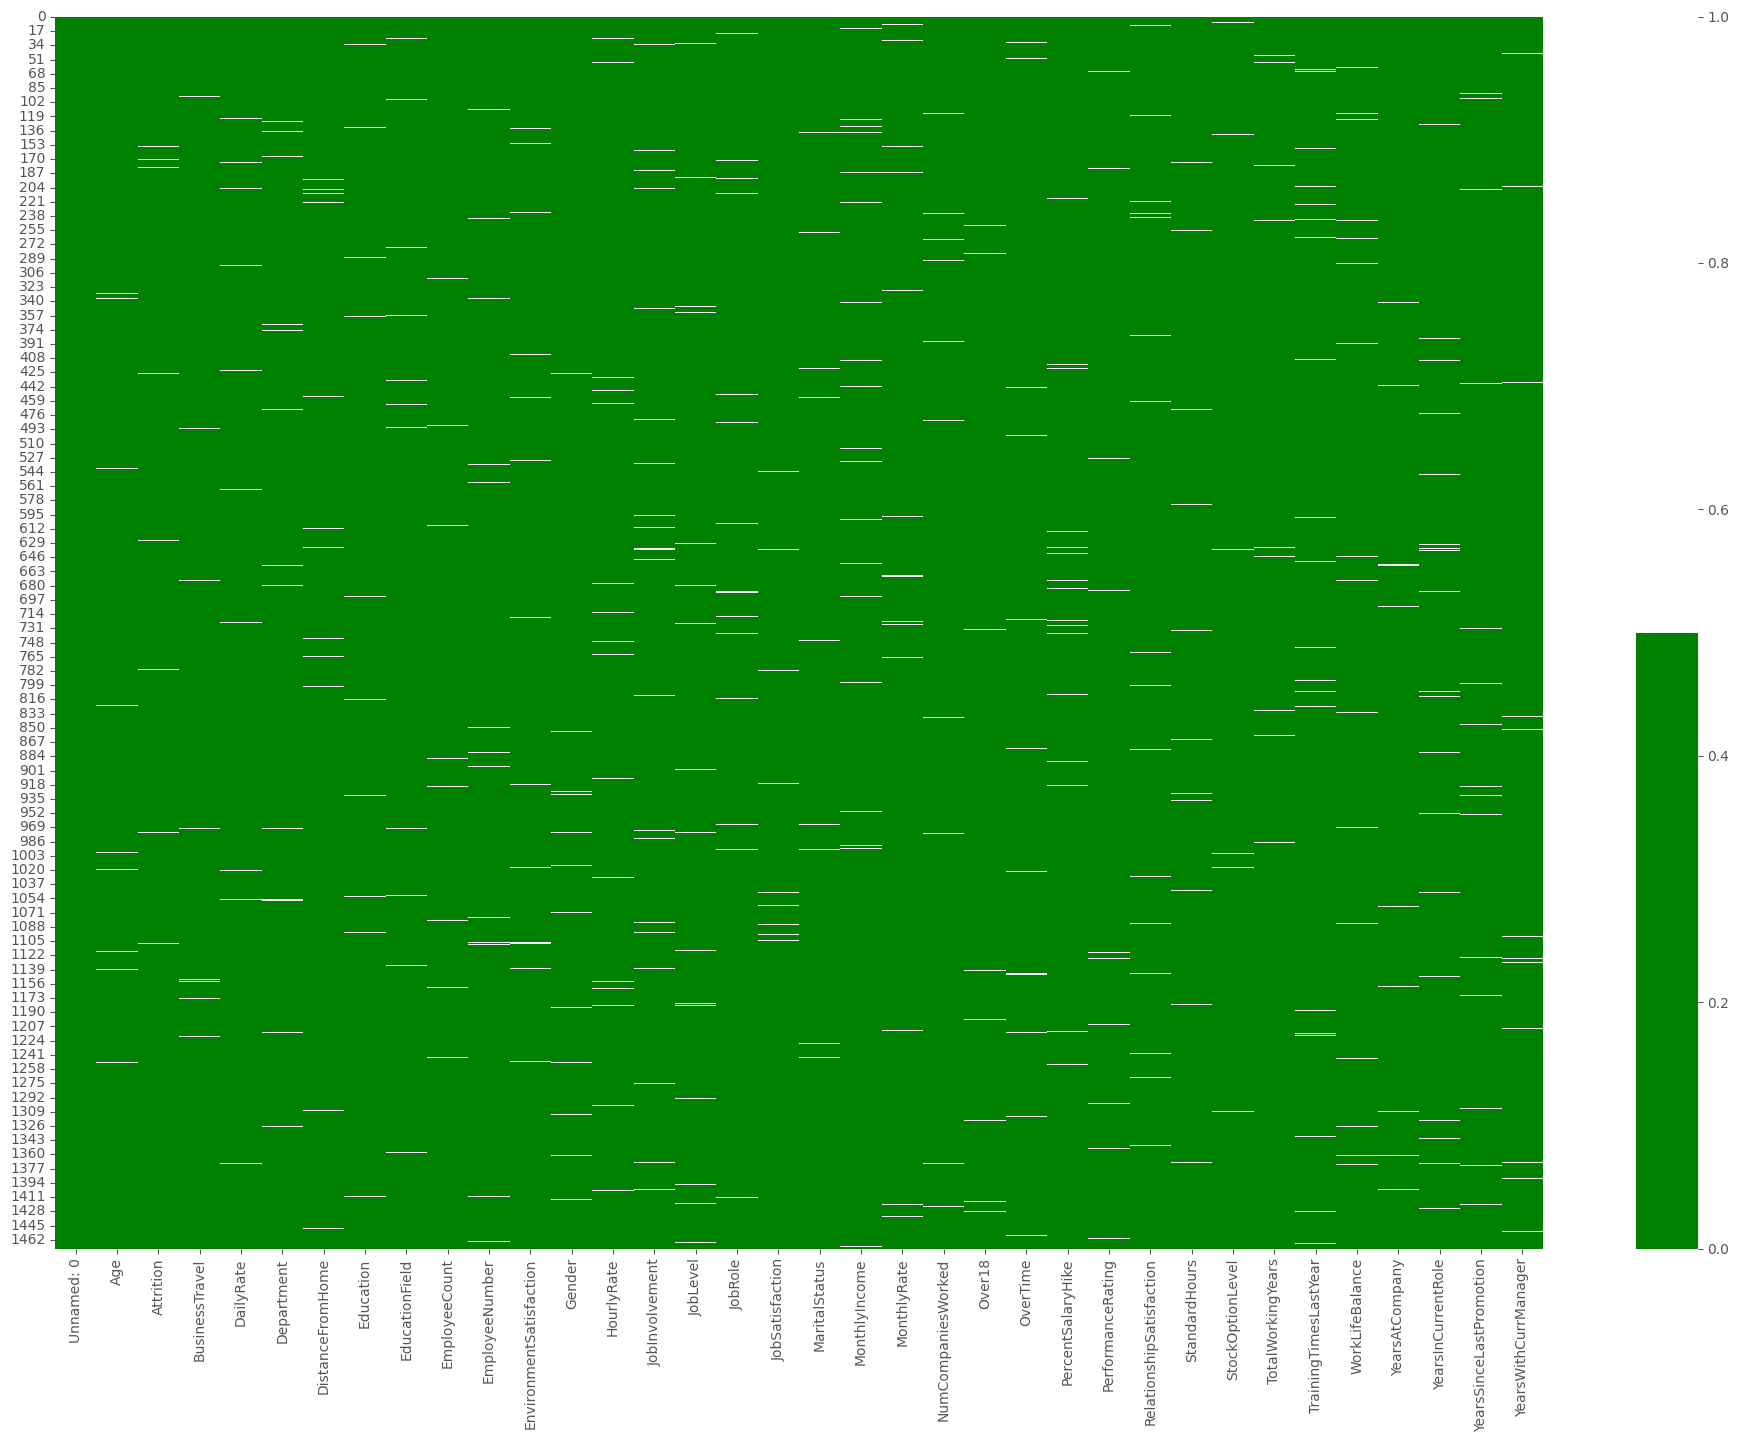

In [ ]:
cols = df.columns # Посмотрим пропуски во всех колонках
# Определяем цвета
# Белый - пропущенные данные, зеленый - не пропущенные
colors = ['green', 'white']
a = sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colors))

Визуально пропусков не очень много и они не сосредоточены в какой-то области, конкретном столбце или строке.

In [ ]:
# Посчитаем абсолютное количество пропусков в каждом столбце
missing_counts = df.isna().sum()
missing_counts


,0
Unnamed: 0,0
Age,12
Attrition,9
BusinessTravel,9
DailyRate,12
Department,17
DistanceFromHome,13
Education,13
EducationField,12
EmployeeCount,10


Видим, что пропуски есть во всех информативных столбцах

In [ ]:
# Отсортируем столбцы по количеству пропусков по убыванию и посчитаем их долю в общем числе значений
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100)
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]


,missing_count,missing_pct
JobInvolvement,22,1.493551
YearsInCurrentRole,21,1.425662
MonthlyIncome,21,1.425662
TrainingTimesLastYear,21,1.425662
HourlyRate,19,1.289885
WorkLifeBalance,19,1.289885
RelationshipSatisfaction,18,1.221996
PercentSalaryHike,18,1.221996
JobLevel,17,1.154107
Department,17,1.154107


Видим, что доля пропущенных значений в каждом из столбцов небольшая, но, судя по тепловой карте, в каждом столбце это разные строки.

Для удаления пропусков сделаем следующее.
1. Удалим строки с отсутствующим значением целевой переменной Attrition, так как без этих значений строки нельзя использовать для моделирования.

In [ ]:
df = df.dropna(subset=['Attrition'])
print('Размер датасета (количество строк, столбцов):', df.shape)

Размер датасета (количество строк, столбцов): (1464, 36)


Видим, что размер датасета уменьшился на 9 строк.теперь обратим внимание на столбцы с "техническими" данными, не имеющими вариантивности.

In [ ]:
df['EmployeeCount'].value_counts(dropna=False)

,count
EmployeeCount,
1.0,1454
NaN,10


В столбце 'EmployeeCount' один тип заполнения - единица и 10 пропусков. Можно либо дозаполнять пропуски также единицами, либо удалить этот столбец как неинформативный.

In [ ]:
df = df.drop(columns=['EmployeeCount'])

In [ ]:
df['Over18'].value_counts(dropna=False)

,count
Over18,
Y,1453
NaN,11


В столбце 'Over18' тоже встречается только одно значение - Y и 11 пропусков. Кстати, можем сопоставить пропущенные значения с реальным возрастом сотрудникво из столбца 'Age'

In [ ]:
# Маска пропусков Over18
mask_over18_na = df['Over18'].isna()

# Таблица строк, где Over18 пропущен
cols_to_show = [c for c in ['EmployeeNumber', 'Age', 'Over18'] if c in df.columns]
display(df.loc[mask_over18_na, cols_to_show].sort_values('Age'))


,EmployeeNumber,Age,Over18
732,1017.0,30.0,NaN
1319,1853.0,32.0,NaN
1428,2013.0,32.0,NaN
1199,1682.0,36.0,NaN
1173,1651.0,36.0,NaN
1416,1995.0,38.0,NaN
1124,1588.0,39.0,NaN
1140,1608.0,44.0,NaN
249,341.0,45.0,NaN
1020,1438.0,47.0,NaN


Видим, что у всех сотрудников с пропущенным полем 'Over18' возраст больше 18 лет, значит этот признак для нас тоже неиформативен и этот столбец можно удалить.

In [ ]:
df = df.drop(columns=['Over18'])

In [ ]:
df['StandardHours'].value_counts(dropna=False)

,count
StandardHours,
80.0,1450
NaN,13
-100.0,1


В столбце 'StandardHours' 1450 одинаковых положительных значений (= 80), 13 пропущенных и одно аномальное, отрицательное (= -100), но тоже по этой причине неинформативное. Можно удалить этот столбец.

In [ ]:
df = df.drop(columns=['StandardHours'])
print('Размер датасета (количество строк, столбцов):', df.shape)

Размер датасета (количество строк, столбцов): (1464, 33)


Видим, что количество столбцов сократилось на 3 неинформативных признака.

Заполним пропуски в значениях числовых признаков средним значением, а вкатегориальных - наиболее часто встречающимся (модой).

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Числовые: NaN -> округлённое среднее (остается float)
df[num_cols] = df[num_cols].fillna(df[num_cols].mean().round(0))

# Категориальные: NaN -> мода
df[cat_cols] = df[cat_cols].apply(lambda s: s.fillna(s.mode()[0]))

print('Размер датасета (количество строк, столбцов):', df.shape)
print("Пропусков после заполнения:", df.isna().sum().sum())
print('Типы данных по столбцам:\n', df.dtypes)

Размер датасета (количество строк, столбцов): (1464, 33)
Пропусков после заполнения: 0
Типы данных по столбцам:
 Unnamed: 0                    int64
Age                         float64
Attrition                    object
BusinessTravel               object
DailyRate                   float64
Department                   object
DistanceFromHome            float64
Education                   float64
EducationField               object
EmployeeNumber              float64
EnvironmentSatisfaction     float64
Gender                       object
HourlyRate                  float64
JobInvolvement              float64
JobLevel                    float64
JobRole                      object
JobSatisfaction             float64
MaritalStatus                object
MonthlyIncome               float64
MonthlyRate                 float64
NumCompaniesWorked          float64
OverTime                     object
PercentSalaryHike           float64
PerformanceRating           float64
RelationshipSatisfactio

In [ ]:
# Снова посмотрим на количество пропусков в оставшихся столбцах
missing_counts = df.isna().sum()
missing_counts

,0
Unnamed: 0,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeNumber,0


Пропусков нет, типы данных по столбцам остались прежними

**1.2. Переходим к проверке невозможных/подозрительных значений**

Посмотрим основные статистики по числовым данным

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

summary = df[num_cols].agg(['min','max','mean','median']).T
summary['nunique'] = df[num_cols].nunique()
summary.sort_values('min').head(20)


,min,max,mean,median,nunique
Unnamed: 0,0.0,1472.0,737.129781,737.5,1464
NumCompaniesWorked,0.0,9.0,2.694672,2.0,10
YearsInCurrentRole,0.0,18.0,4.217213,3.0,19
YearsSinceLastPromotion,0.0,15.0,2.196038,1.0,16
YearsAtCompany,0.0,40.0,7.030738,5.0,37
TrainingTimesLastYear,0.0,6.0,2.807377,3.0,7
TotalWorkingYears,0.0,40.0,11.318306,10.0,40
StockOptionLevel,0.0,3.0,0.797131,1.0,4
YearsWithCurrManager,0.0,17.0,4.112022,3.0,18
JobLevel,1.0,5.0,2.066940,2.0,5


In [ ]:
issues = {}

# Отрицательных быть не должно (возраст, доходы, стажи, расстояние и т.п.)
nonneg_cols = [
    'Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome','MonthlyRate',
    'NumCompaniesWorked','PercentSalaryHike','StockOptionLevel',
    'TotalWorkingYears','TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole',
    'YearsSinceLastPromotion','YearsWithCurrManager'
]
nonneg_cols = [c for c in nonneg_cols if c in df.columns]
for c in nonneg_cols:
    bad = df[df[c] < 0]
    if len(bad) > 0:
        issues[c] = bad

# Возраст: разумный диапазон (16–80)
if 'Age' in df.columns:
    issues['Age_out_of_range'] = df[(df['Age'] < 16) | (df['Age'] > 80)]

# Проценты: от 0 до 100
for c in ['PercentSalaryHike']:
    if c in df.columns:
        issues[c+'_out_of_range'] = df[(df[c] < 0) | (df[c] > 100)]

# Рейтинг/ шкалы
bounded = {
    'Education': (1, 5),
    'EnvironmentSatisfaction': (1, 4),
    'JobInvolvement': (1, 4),
    'JobLevel': (1, 5),
    'JobSatisfaction': (1, 4),
    'PerformanceRating': (1, 4),
    'RelationshipSatisfaction': (1, 4),
    'WorkLifeBalance': (1, 4),
}
for c,(lo,hi) in bounded.items():
    if c in df.columns:
        issues[c+'_out_of_range'] = df[(df[c] < lo) | (df[c] > hi)]


In [ ]:
issues = {}

# Стаж не может превышать возраст (самая общая проверка)
if {'Age', 'TotalWorkingYears'}.issubset(df.columns):
    issues['TotalWorkingYears_gt_Age'] = df[df['TotalWorkingYears'] > df['Age']]

# Годы в компании не должны превышать общий стаж
if {'YearsAtCompany', 'TotalWorkingYears'}.issubset(df.columns):
    issues['YearsAtCompany_gt_TotalWorkingYears'] = df[df['YearsAtCompany'] > df['TotalWorkingYears']]

# Стаж в текущей должности/с менеджером/с момента последнего повышения
#    не должны превышать Стаж работы в компании
cols = ['YearsAtCompany','YearsInCurrentRole','YearsWithCurrManager','YearsSinceLastPromotion']
if set(cols).issubset(df.columns):
    for c in cols[1:]:
        issues[f'{c}_gt_YearsAtCompany'] = df[df[c] > df['YearsAtCompany']]

# Краткий отчёт: сколько проблемных строк по каждому правилу
report = {k: len(v) for k, v in issues.items() if len(v) > 0}
pd.Series(report).sort_values(ascending=False)

,0
YearsAtCompany_gt_TotalWorkingYears,6
YearsInCurrentRole_gt_YearsAtCompany,6
YearsWithCurrManager_gt_YearsAtCompany,6
YearsSinceLastPromotion_gt_YearsAtCompany,2


In [ ]:
cols_to_show = [
    'EmployeeNumber', 'Age',
    'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion',
    'Department', 'JobRole'
]
cols_to_show = [c for c in cols_to_show if c in df.columns]

for name, df_bad in issues.items():
    print(f"\n=== {name} (строк: {len(df_bad)}) ===")
    display(df_bad[cols_to_show].head(10))



=== TotalWorkingYears_gt_Age (строк: 0) ===


,EmployeeNumber,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion,Department,JobRole



=== YearsAtCompany_gt_TotalWorkingYears (строк: 6) ===


,EmployeeNumber,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion,Department,JobRole
178,244.0,46.0,11.0,24.0,13.0,7.0,15.0,Sales,Sales Executive
656,911.0,32.0,1.0,7.0,0.0,1.0,0.0,Research & Development,Laboratory Technician
1064,1499.0,30.0,6.0,7.0,3.0,3.0,1.0,Human Resources,Human Resources
1222,1714.0,24.0,1.0,7.0,0.0,0.0,0.0,Human Resources,Human Resources
1309,1836.0,26.0,5.0,7.0,3.0,2.0,1.0,Sales,Sales Executive
1402,1974.0,31.0,1.0,7.0,0.0,0.0,0.0,Research & Development,Laboratory Technician



=== YearsInCurrentRole_gt_YearsAtCompany (строк: 6) ===


,EmployeeNumber,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion,Department,JobRole
341,461.0,38.0,12.0,7.0,10.0,9.0,2.0,Research & Development,Research Director
547,752.0,42.0,7.0,2.0,4.0,2.0,2.0,Research & Development,Research Scientist
631,874.0,44.0,10.0,3.0,4.0,2.0,0.0,Research & Development,Laboratory Technician
952,1331.0,31.0,3.0,3.0,4.0,2.0,2.0,Sales,Sales Representative
1319,1853.0,32.0,4.0,0.0,4.0,0.0,0.0,Sales,Sales Executive
1371,1935.0,56.0,6.0,0.0,4.0,0.0,0.0,Sales,Sales Executive



=== YearsWithCurrManager_gt_YearsAtCompany (строк: 6) ===


,EmployeeNumber,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion,Department,JobRole
341,461.0,38.0,12.0,7.0,10.0,9.0,2.0,Research & Development,Research Director
437,585.0,30.0,4.0,3.0,2.0,4.0,1.0,Sales,Sales Representative
1126,1591.0,50.0,27.0,1.0,0.0,4.0,0.0,Sales,Manager
1159,1633.0,39.0,10.0,7.0,2.0,8.0,3.0,Research & Development,Manufacturing Director
1209,1697.0,60.0,19.0,1.0,0.0,4.0,0.0,Research & Development,Healthcare Representative
1234,1731.0,47.0,4.0,1.0,0.0,4.0,0.0,Sales,Sales Executive



=== YearsSinceLastPromotion_gt_YearsAtCompany (строк: 2) ===


,EmployeeNumber,Age,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,YearsSinceLastPromotion,Department,JobRole
731,1016.0,20.0,1.0,1.0,0.0,0.0,2.0,Research & Development,Research Scientist
797,1107.0,26.0,1.0,1.0,1.0,0.0,2.0,Research & Development,Laboratory Technician


Мы видим следующие невозможные (или очень подозрительыне) значения по данным сотрудников:

1. В 6 строках общий стаж работы меньше стажа работы в данной компании;

2. В 6 строках стаж работы в данной компании меньше стажа работы в текущей должности;

3. В 6 строках стаж работы в данной компании меньше стажа работы с текущим руководителем;

4. В 2 строках стаж работы в данной компании меньше стажа работы с момента последнего повышения.



**2. Дубликаты и консистентность**

In [ ]:
# Определяем столбцы, по которым ищем полные дубликаты (без учета первого безымянного столбца с порядковым номером)
if 'Unnamed: 0' in df.columns:
    dup_cols = df.columns.drop('Unnamed: 0')
else:
    dup_cols = df.columns  # если столбец удален

# Считаем полные дубликаты без учёта тех. столбца
full_dups_mask = df.duplicated(subset=dup_cols)
full_dups_count = full_dups_mask.sum()
print("Количество полных дубликатов (без учёта 'Unnamed: 0'):", full_dups_count)

# Посмотреть сами дубликаты
if full_dups_count > 0:
    display(df[full_dups_mask].head(10))

Количество полных дубликатов (без учёта 'Unnamed: 0'): 3


,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1470,1470,50.0,No,Travel_Frequently,809.0,Sales,12.0,3.0,Marketing,174.0,...,3.0,4.0,0.0,16.0,3.0,3.0,2.0,2.0,2.0,1.0
1471,1471,22.0,No,Non-Travel,457.0,Research & Development,26.0,2.0,Other,1605.0,...,3.0,2.0,0.0,4.0,2.0,2.0,4.0,2.0,1.0,3.0
1472,1472,51.0,No,Travel_Rarely,770.0,Human Resources,5.0,3.0,Life Sciences,1352.0,...,3.0,2.0,1.0,33.0,2.0,3.0,33.0,9.0,0.0,10.0


В датасете найдены 3 дубликата имеющихся строк (не считая 0 столбца с порядковым номером). Удалим их.

In [ ]:
# Удалить полные дубликаты
df = df.drop_duplicates(subset=dup_cols, keep='first')
print("Размер датасета после удаления полных дублей:", df.shape)

Размер датасета после удаления полных дублей: (1461, 33)


In [ ]:
dups_mask_after = df.duplicated(subset=dup_cols, keep=False)
print("Дублей после удаления:", dups_mask_after.sum())

# На всякий случай можно проверить, что датасет без дублей
if dups_mask_after.sum() == 0:
    print("Полные дубликаты действительно отсутствуют.")
else:
    display(df[dups_mask_after].head(10))


Дублей после удаления: 0
Полные дубликаты действительно отсутствуют.


В данных присутствует столбец EmployeeNumber, который по названию выглядит как идентификатор сотрудника. Выполним проверку частичных дубликатов по этому полю.

In [ ]:
if 'EmployeeNumber' in df.columns:
    emp_dups = df.duplicated(subset=['EmployeeNumber']).sum()
    print("Дубликатов по EmployeeNumber:", emp_dups)

    display(df[df.duplicated(subset=['EmployeeNumber'], keep=False)]
            .sort_values('EmployeeNumber')
            .head(30))


Дубликатов по EmployeeNumber: 14


,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
111,111,34.0,Yes,Travel_Frequently,658.0,Research & Development,7.0,3.0,Life Sciences,1025.0,...,4.0,4.0,0.0,9.0,3.0,3.0,9.0,7.0,0.0,6.0
241,241,32.0,No,Non-Travel,976.0,Sales,26.0,4.0,Marketing,1025.0,...,3.0,1.0,0.0,4.0,2.0,3.0,3.0,2.0,2.0,2.0
337,337,37.0,No,Travel_Rarely,738.0,Research & Development,9.0,5.0,Other,1025.0,...,3.0,3.0,0.0,4.0,2.0,3.0,3.0,2.0,2.0,2.0
535,535,41.0,No,Travel_Rarely,427.0,Human Resources,10.0,4.0,Human Resources,1025.0,...,3.0,2.0,3.0,23.0,2.0,2.0,21.0,6.0,12.0,6.0
557,557,35.0,No,Non-Travel,1225.0,Research & Development,2.0,4.0,Life Sciences,1025.0,...,3.0,1.0,1.0,16.0,2.0,4.0,1.0,0.0,0.0,0.0
737,737,41.0,No,Travel_Rarely,549.0,Research & Development,7.0,2.0,Medical,1025.0,...,3.0,2.0,0.0,8.0,6.0,3.0,2.0,2.0,2.0,1.0
850,850,32.0,No,Non-Travel,862.0,Sales,2.0,1.0,Life Sciences,1025.0,...,3.0,3.0,3.0,1.0,3.0,3.0,1.0,0.0,0.0,0.0
879,879,60.0,No,Travel_Rarely,696.0,Sales,7.0,4.0,Marketing,1025.0,...,3.0,2.0,1.0,12.0,3.0,3.0,11.0,4.0,1.0,9.0
896,896,31.0,No,Travel_Rarely,1062.0,Research & Development,24.0,3.0,Medical,1025.0,...,3.0,2.0,0.0,10.0,2.0,3.0,10.0,9.0,1.0,8.0
1077,1077,29.0,Yes,Travel_Rarely,224.0,Research & Development,1.0,4.0,Technical Degree,1025.0,...,3.0,3.0,0.0,11.0,2.0,1.0,9.0,7.0,0.0,7.0


Проверка показала, что в датасете есть 15 строк с одинаковым кодом сотрудника (1025), но остальные поля не совпадают.

Просмотр строк с повторяющимся значением показал, что для одного и того же EmployeeNumber (остальные признаки (возраст, отдел, должность, удовлетворённость и т.д.) существенно отличаются.
Это означает, что в данном датасете EmployeeNumber не является уникальным идентификатором сотрудника, а скорее представляет собой некоторый код/ категориальный признак.
Поэтому удалять строки, основываясь только на совпадении EmployeeNumber, некорректно: это привело бы к потере ценных, релевантных наблюдений. В рамках EDA столбец EmployeeNumber будем рассматривать как обычный категориальный/технический признак, а не как ключ для поиска дубликатов.

Остальные поля датасета не имеют признаки уникальности, соответственно, возможны размичные сочетания призаков, как повторяющихся, так и отличных друг от друга, и по этим совпадениям ии различиям невозможно сделать вывод о дублировании информации, ее корректности или некорректности.

**3. Выбросы в числовых признаках**

In [ ]:
# Проверяем наличие столбцов с призаками в таблице (что мы ничего не удалили ранее как неиформативные или "служебные" признаки). Дальше будем использовать их для анализа выбросов.

num_cols_candidate = [
    'Age', 'DistanceFromHome',
    'MonthlyIncome', 'MonthlyRate', 'DailyRate', 'HourlyRate',
    'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsWithCurrManager', 'YearsSinceLastPromotion',
    'NumCompaniesWorked', 'TrainingTimesLastYear',
    'PercentSalaryHike'
]

num_cols_iqr = [c for c in num_cols_candidate if c in df.columns]
num_cols_iqr


['Age',
 'DistanceFromHome',
 'MonthlyIncome',
 'MonthlyRate',
 'DailyRate',
 'HourlyRate',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsWithCurrManager',
 'YearsSinceLastPromotion',
 'NumCompaniesWorked',
 'TrainingTimesLastYear',
 'PercentSalaryHike']

In [ ]:
# Поиск выбросов методом IQR
outlier_info = []

for c in num_cols_iqr:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_lower = df[c] < lower
    mask_upper = df[c] > upper
    n_lower = mask_lower.sum()
    n_upper = mask_upper.sum()
    n_total = n_lower + n_upper

    outlier_info.append({
        'feature': c,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_lower': n_lower,
        'n_upper': n_upper,
        'n_outliers': n_total
    })

outlier_df = pd.DataFrame(outlier_info).set_index('feature').sort_values('n_outliers', ascending=False)
outlier_df


,Q1,Q3,IQR,lower_bound,upper_bound,n_lower,n_upper,n_outliers
feature,,,,,,,,
TrainingTimesLastYear,2.0,3.0,1.0,0.5,4.5,53,181,234
MonthlyIncome,2932.0,8008.0,5076.0,-4682.0,15622.0,0,125,125
YearsSinceLastPromotion,0.0,3.0,3.0,-4.5,7.5,0,107,107
YearsAtCompany,3.0,9.0,6.0,-6.0,18.0,0,103,103
TotalWorkingYears,6.0,15.0,9.0,-7.5,28.5,0,63,63
NumCompaniesWorked,1.0,4.0,3.0,-3.5,8.5,0,52,52
YearsInCurrentRole,2.0,7.0,5.0,-5.5,14.5,0,21,21
YearsWithCurrManager,2.0,7.0,5.0,-5.5,14.5,0,14,14
HourlyRate,48.0,83.0,35.0,-4.5,135.5,0,0,0


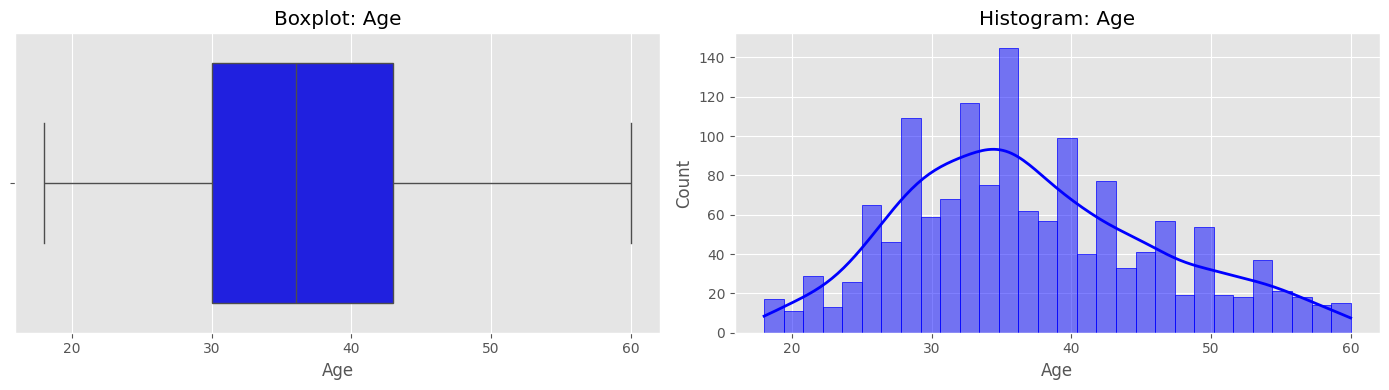

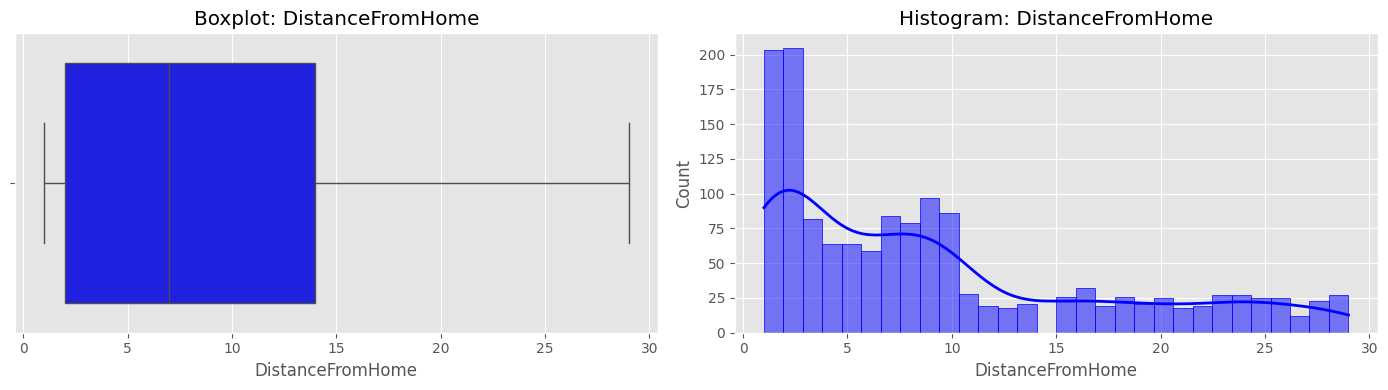

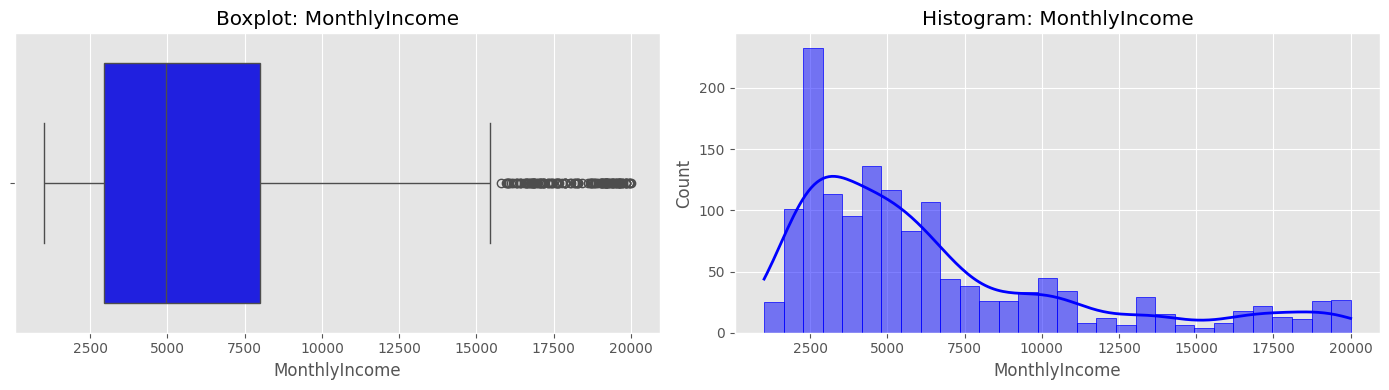

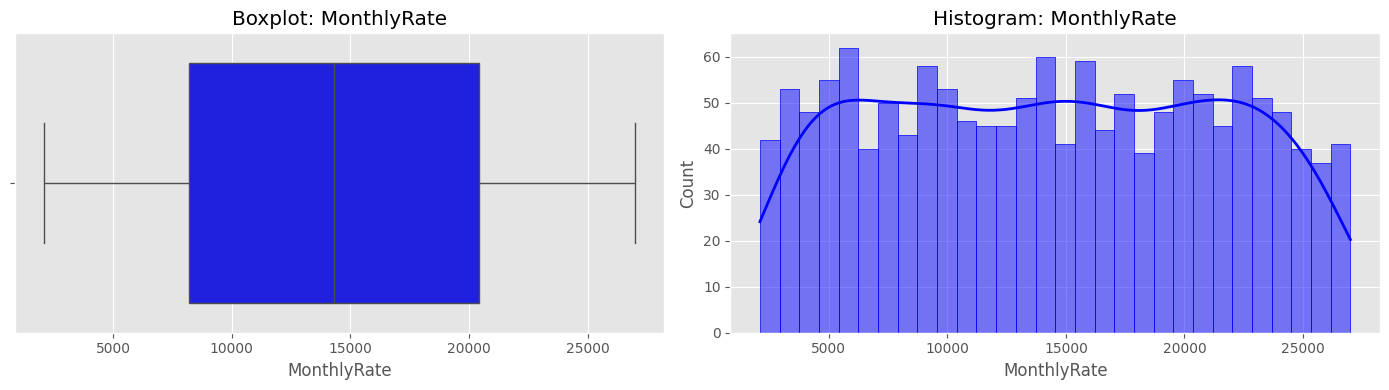

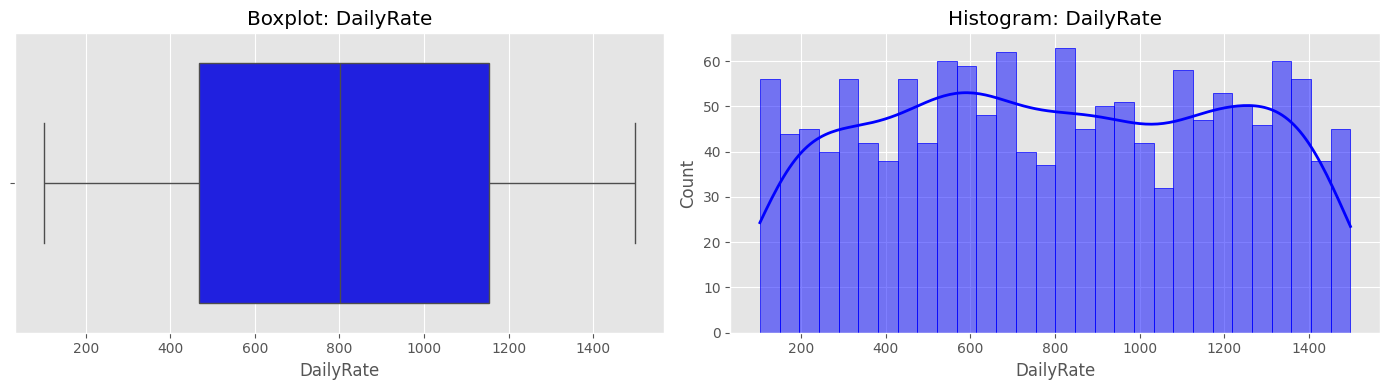

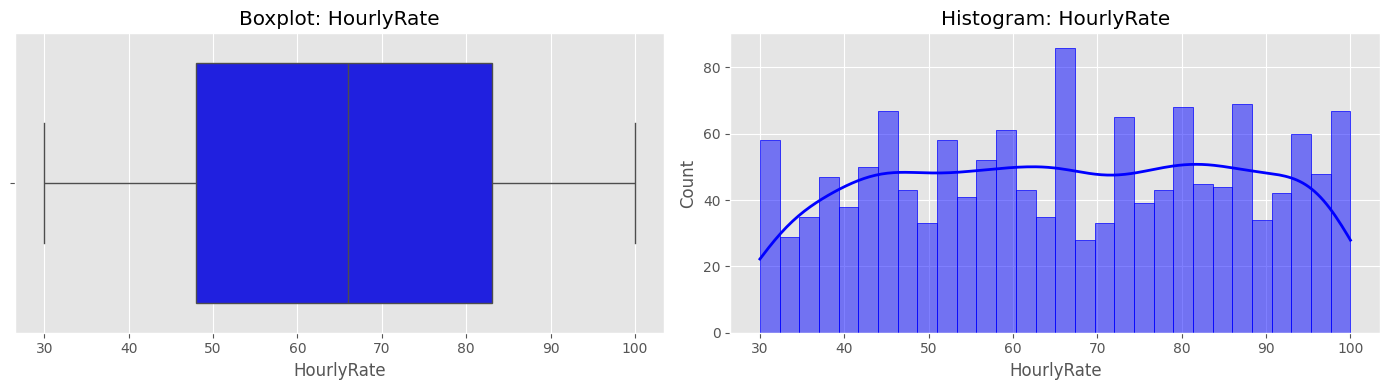

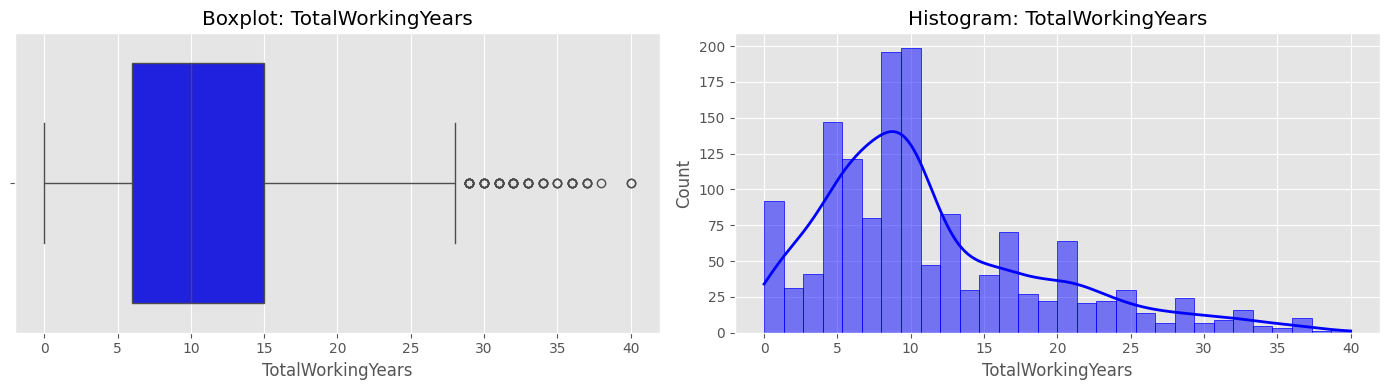

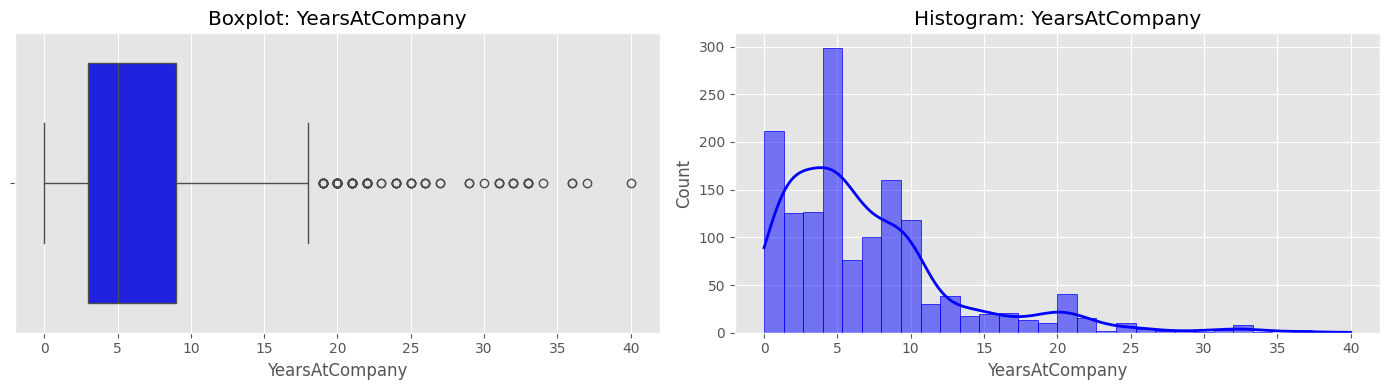

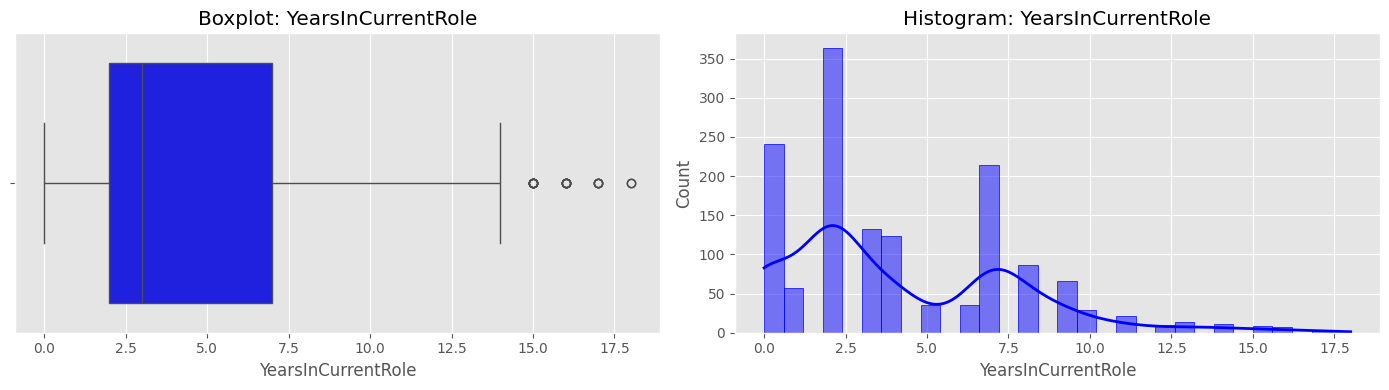

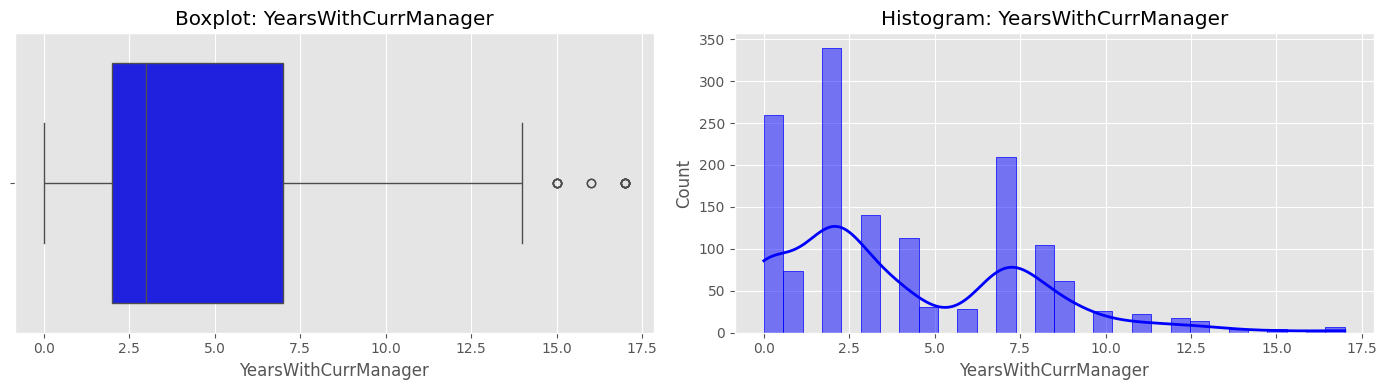

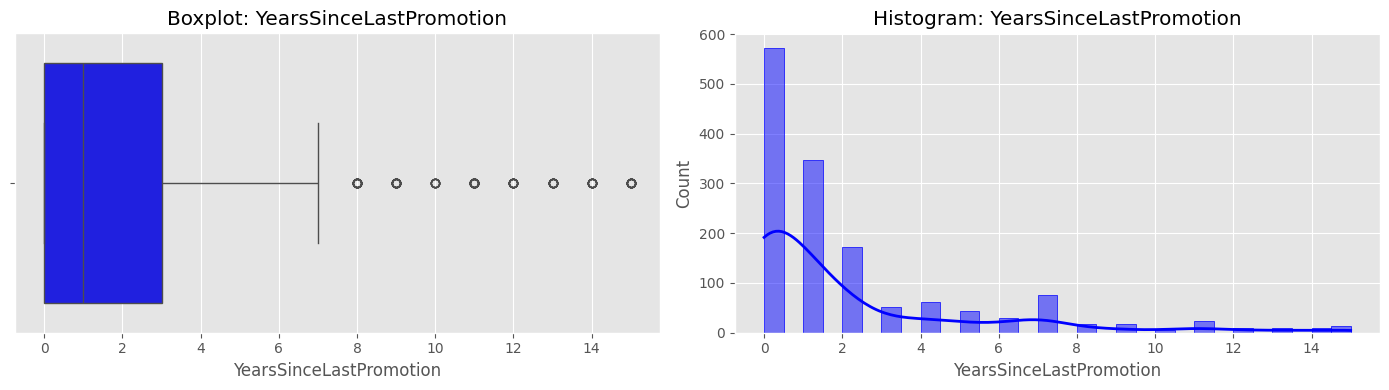

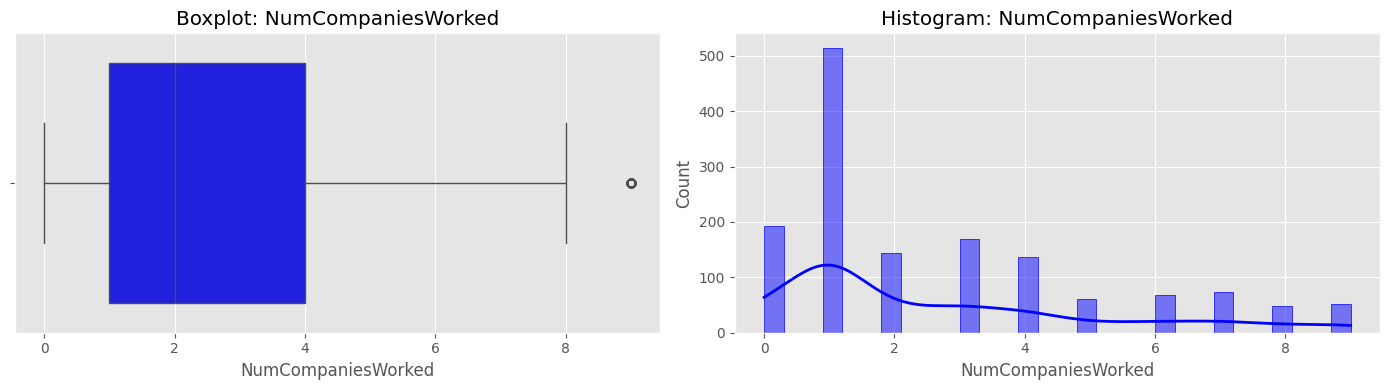

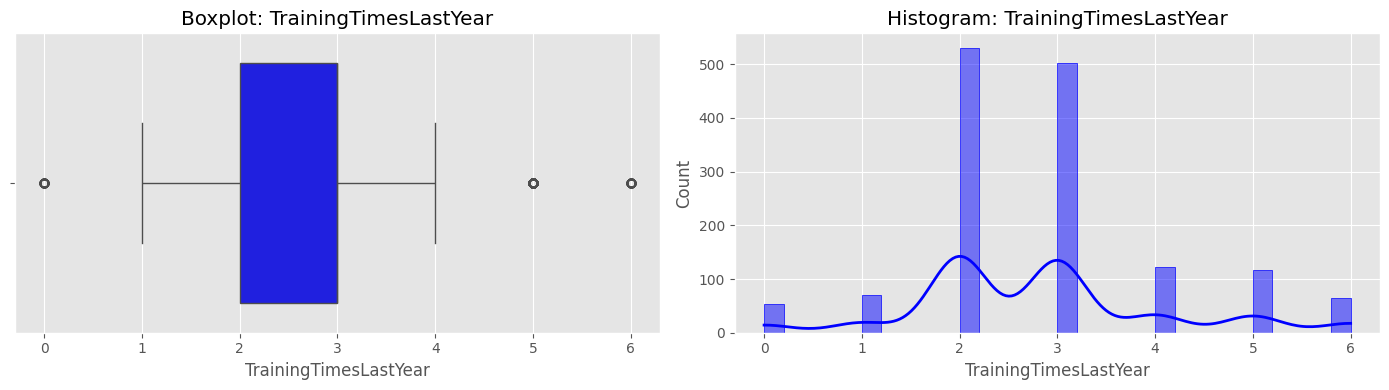

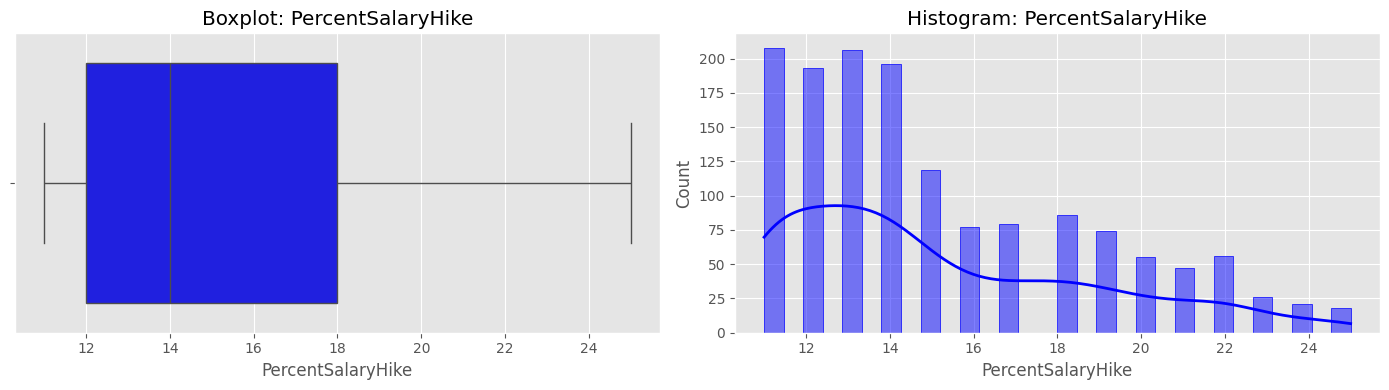

In [ ]:
# Выполним визуализации - "ящики с усами" и гистрограммы
for c in num_cols_iqr:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # boxplot
    sns.boxplot(x=df[c], ax=axes[0], color='blue')
    axes[0].set_title(f'Boxplot: {c}')

    # гистограмма
    sns.histplot(df[c], bins=30, kde=True, color='blue', edgecolor='blue', line_kws={'color': 'blue', 'linewidth': 2}, ax=axes[1])
    axes[1].set_title(f'Histogram: {c}')

    plt.tight_layout()
    plt.show()


**Стратегия работы с выбросами**

В рамках EDA метод IQR используется для выявления потенциальных выбросов и визуальной диагностики распределений.

После предварительной очистки (удаление/исправление логически невозможных значений) оставшиеся “выбросы” по IQR интерпретируются как реальные крайние значения (например, сотрудники с высоким доходом или большим стажем), а не как ошибки.

Поскольку доля таких наблюдений невелика и они не противоречат бизнес-логике, можно не удалять и не модифицировать их, а лишь учитывать наличие “тяжелых хвостов” при дальнейшем анализе и выборе метрик/моделей.

Для доходного признака - Ежемесячного дохода (MonthlyIncome) может быть применена мягкая обработка выбросов (winsorization): значения ниже 1-го и выше 99-го перцентилей будут удалены до границ этого интервала.
Это снижает влияние единичных экстремальных наблюдений на статистики и модели, при этом большая часть распределения остаётся неизменной.

Однако следует отметить, что правый "хвост" данного признака, исходя из построенной гистораммы, не является абсолютно убывающим и в районе максимальных значений имеет достаточно выраженный размер столбцов, что говорит о реальном наличии менеджеров с высокими зарплатами (19000-20000$), и полностью исключать их из расчета неверно. Соответвенно, решение о выполнении или невыполнении данной обработки надо принимать в зависимости от дальнейшей цели использования обрабатываемых данных.

In [ ]:
cap_cols = [c for c in ['MonthlyIncome'] if c in df.columns]

for c in cap_cols:
    lower = df[c].quantile(0.01)  # 1-й перцентиль
    upper = df[c].quantile(0.99)  # 99-й перцентиль
    df[c] = df[c].clip(lower=lower, upper=upper)


**4. Обработка категориальных признаков**

In [ ]:
# Выделяем категориальные признаки по типу данных 'object'
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols


['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [ ]:
# Сразу отметим ординальные признаки со шкалами (или качественные категориальные признаки с уже имеющейся шкалой)
ordinal_num_cols = [c for c in [
    'Education',                # 1-5
    'JobLevel',                 # 1-5
    'EnvironmentSatisfaction',  # 1-4
    'JobInvolvement',           # 1-4
    'JobSatisfaction',          # 1-4
    'PerformanceRating',        # 1-4
    'RelationshipSatisfaction', # 1-4
    'WorkLifeBalance',          # 1-4
    'StockOptionLevel'          # 0-3 (можно тоже считать упорядоченным)
] if c in df.columns]
ordinal_num_cols


['Education',
 'JobLevel',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobSatisfaction',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'WorkLifeBalance',
 'StockOptionLevel']

Перекодируем ординальный признак 'BusinessTravel'

In [ ]:
# Сделаем категориальную кодировку для признака 'BusinessTravel'
bt_order = {
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
}

if 'BusinessTravel' in df.columns:
    df['BusinessTravel_ord'] = df['BusinessTravel'].map(bt_order)


Перекодируем номинальные признаки

In [ ]:
# Выбираем оставшиеся категориальные признаки без естественного порядка (все со значением 'object', кроме перекодированного выше 'BusinessTravel')
nominal_cat_cols = [c for c in cat_cols if c not in ['BusinessTravel']]
nominal_cat_cols


['Attrition',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [ ]:
# Сделаем бинарным признак'Attrition'
if 'Attrition' in df.columns:
    df['Attrition_flag'] = df['Attrition'].map({'No': 0, 'Yes': 1})


In [ ]:
# Сделаем бинарным признак'OverTime'
if 'OverTime' in df.columns:
    df['OverTime_flag'] = df['OverTime'].map({'No': 0, 'Yes': 1})

In [ ]:
# Проверяем, какие качественные признаки остались без присвоенного порядка
nominal_for_dummies = [c for c in nominal_cat_cols
                       if c not in ['Attrition', 'OverTime']]

nominal_for_dummies

['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

In [ ]:
# Для оставшихся признаком делаем one-hot-encoding
df_encoded = pd.get_dummies(df, columns=nominal_for_dummies, drop_first=True) #drop_first=True - убираем по одной колонке в каждой группе, чтобы избежать жёсткой мультиколлинеарности, если False - будут все колонки

df_encoded.shape # новый размер датасета


(1461, 49)

In [ ]:
df_encoded.columns.tolist() # Посмотрим новый список колонок


['Unnamed: 0',
 'Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'BusinessTravel_ord',
 'Attrition_flag',
 'OverTime_flag',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Sci

**Вывод:**

Обработка категориальных признаков.
В наборе данных выделены категориальные признаки (dtype=object): Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime.

Ординальные признаки.
К ординальным отнесены: Education, JobLevel, EnvironmentSatisfaction, JobInvolvement, JobSatisfaction, PerformanceRating, RelationshipSatisfaction, WorkLifeBalance, StockOptionLevel (шкалы 1-4/ 1-5 /0-3), а также BusinessTravel, для которого задан порядок уровней.
Для BusinessTravel создан ординальный числовой признак BusinessTravel_ord с кодами 0/1/2, остальные ординальные признаки уже представлены числовыми значениями и дополнительных преобразований не требовали.

Номинальные признаки.
К номинальным отнесены: Department, EducationField, Gender, JobRole, MaritalStatus, OverTime, а также Attrition как целевая переменная (Yes/No).
Цель Attrition перекодирована в бинарный признак Attrition_flag (No=0, Yes=1). Бинарный признак OverTime также перекодирован в 0/1. Остальные номинальные признаки закодированы методом one-hot-encoding.

**5. Масштабирование числовых признаков**

Перед масштабированием удалим первый столбец с порядковыми номерами строк как неиформативный.

In [ ]:
if 'Unnamed: 0' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['Unnamed: 0'])

Для масштабирования выберем RobustScaler, так как в числовых признаках (например, MonthlyIncome) наблюдаются выбросы/скошенные распределения. RobustScaler использует медиану и IQR, поэтому менее чувствителен к выбросам и распределению данных, отличному от нормального, по сравнению со StandardScaler/MinMaxScaler.

Хотя часть категориальных признаков в датасете представлена числами (например, шкалы 1-4/ 1-5), по смыслу они являются ординальными категориями, а не количественными величинами. Поэтому в данном пункте для масштабирования под “числовыми признаками” рассматриваются признаки с количественным смыслом (доход, ставки, стаж, расстояние и т.д.). Ординальные шкалы, бинарные признаки и технический идентификатор (EmployeeNumber) масштабированию не подвергались,  так как они либо являются категориальными по смыслу, либо уже находятся в небольшом диапазоне и их “расстояния” интерпретируются условно.

In [ ]:
from sklearn.preprocessing import RobustScaler

df_scaled = df_encoded.copy()

# Признаки, которые реально имеет смысл масштабировать
scale_cols = [c for c in [
    'Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome','MonthlyRate',
    'NumCompaniesWorked','PercentSalaryHike','TotalWorkingYears','TrainingTimesLastYear',
    'YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager'
] if c in df_scaled.columns]

print("Масштабируем:", len(scale_cols), scale_cols)

scaler = RobustScaler()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])


Масштабируем: 14 ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
# Проверим медиану и IQR количественных признаков после масштабирования
check = pd.DataFrame({
    'median_after': df_scaled[scale_cols].median(),
    'IQR_after': df_scaled[scale_cols].quantile(0.75) - df_scaled[scale_cols].quantile(0.25)
}).round(3)

display(check)


,median_after,IQR_after
Age,0.0,1.0
DailyRate,0.0,1.0
DistanceFromHome,0.0,1.0
HourlyRate,0.0,1.0
MonthlyIncome,0.0,1.0
MonthlyRate,0.0,1.0
NumCompaniesWorked,0.0,1.0
PercentSalaryHike,0.0,1.0
TotalWorkingYears,0.0,1.0
TrainingTimesLastYear,0.0,1.0


Видим. что после масштабирования у выбранных количественных признаков медиана стала равной 0, а межвкартильный размах = 1, что свидетельствует об успешно выполненном масштабировании.